<a href="https://colab.research.google.com/github/keertiam8/gnn-congestion/blob/main/gnn_congestion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# cell A
import shutil, os
shutil.rmtree("/content/closed-loop-placement", ignore_errors=True)
os.chdir("/content")
!git clone https://github.com/keertiam8/gnn-congestion closed-loop-placement
os.chdir("/content/closed-loop-placement")
!git log --oneline -3


Cloning into 'closed-loop-placement'...
remote: Enumerating objects: 65, done.
remote: Counting objects: 100% (65/65), done.
remote: Compressing objects: 100% (47/47), done.
Receiving objects: 100% (65/65), 468.80 KiB | 1.85 MiB/s, done.
remote: Total 65 (delta 30), reused 41 (delta 14), pack-reused 0 (from 0)
Resolving deltas: 100% (30/30), done.
8b09435 (HEAD -> main, origin/main, origin/HEAD) Created using Colab
37f2f34 Fix archive paths to match CircuitNet's actual Drive layout
4c7de80 Created using Colab


In [2]:
# cell B
!pip install --quiet gdown scipy scikit-image


In [3]:
# updated config -- now 4 archives
with open('scripts/colab_prepare_congestion_data.py', 'r') as f:
    content = f.read()

content = content.replace(
    '"macro_region": {\n        "source": "FILL_ME_IN",',
    '"macro_region": {\n        "source": "14n9khpSK56NUZrGUNPPRYmZkAbCOstKq",'
)
content = content.replace(
    '"rudy": {\n        "source": "FILL_ME_IN",',
    '"rudy": {\n        "source": "1KUocSofLvyAFKXu8AXt4j3TPJsiaCjS6",'
)
content = content.replace(
    '"rudy_pin": {\n        "source": "FILL_ME_IN",',
    '"rudy_pin": {\n        "source": "1oRrJ9f9OOitzwlUKHYJh1Gt_KxqUaarK",'
)
content = content.replace(
    '"congestion": {\n        "source": "FILL_ME_IN",',
    '"congestion": {\n        "source": "1aFFT6A32ybvKsTcFZGEQuARa8ipurke_",'
)

with open('scripts/colab_prepare_congestion_data.py', 'w') as f:
    f.write(content)

print("Config updated with all 4 archives")


Config updated with all 4 archives


In [4]:
!python scripts/colab_prepare_congestion_data.py --num-samples 20



=== macro_region ===
downloading...
Downloading...
From: https://drive.google.com/uc?id=14n9khpSK56NUZrGUNPPRYmZkAbCOstKq
To: /content/circuitnet_downloads/macro_region.tar.gz
100% 6.10M/6.10M [00:00<00:00, 40.5MB/s]
picked 20 sample IDs from macro_region
/content/closed-loop-placement/scripts/colab_prepare_congestion_data.py:173: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extract(member, extract_dir)
extracted 20 files from macro_region
deleted /content/circuitnet_downloads/macro_region.tar.gz to free space

=== rudy ===
downloading...
Downloading...
From (original): https://drive.google.com/uc?id=1KUocSofLvyAFKXu8AXt4j3TPJsiaCjS6
From (redirected): https://drive.google.com/uc?id=1KUocSofLvyAFKXu8AXt4j3TPJsiaCjS6&confirm=t&uuid=b74dde4a-5743-43e7-a279-9e09f27ebef4
To: /content/circuitnet_downloads/rudy.tar.gz
100% 2.73G/2.73G [00:39<00:00, 69.7MB/s]


{
  "num_samples": 20,
  "mean_nrmse": 0.041910321544855834,
  "mean_ssim": 0.6180221273039301,
  "mean_mse": 0.0023725334456685234,
  "per_sample": [
    {
      "sample": "10078-zero-riscy-b-3-c5-u0.8-m1-p3-f0.npy",
      "nrmse": 0.014047074131667614,
      "ssim": 0.8272131462067602,
      "mse": 0.00019732030341401696
    },
    {
      "sample": "10083-zero-riscy-b-3-c5-u0.8-m1-p8-f0.npy",
      "nrmse": 0.024598699063062668,
      "ssim": 0.7446428142870035,
      "mse": 0.000605095992796123
    },
    {
      "sample": "1076-RISCY-a-2-c5-u0.85-m4-p7-f0.npy",
      "nrmse": 0.05410758778452873,
      "ssim": 0.2205763897682274,
      "mse": 0.002927631139755249
    },
    {
      "sample": "2018-RISCY-b-1-c2-u0.7-m1-p7-f0.npy",
      "nrmse": 0.03621281310915947,
      "ssim": 0.5856565241249165,
      "mse": 0.0013113677268847823
    },
    {
      "sample": "255-RISCY-a-1-c5-u0.7-m1-p8-f0.npy",
      "nrmse": 0.04885675385594368,
      "ssim": 0.6016243713430619,
      "mse": 

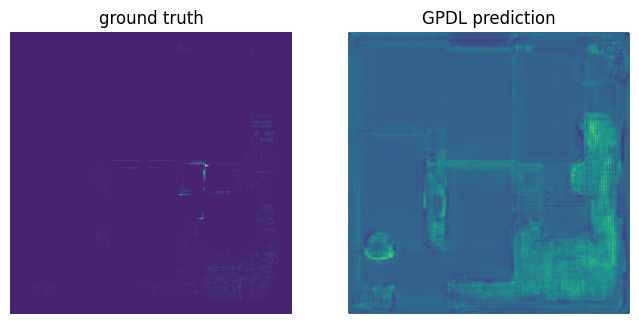

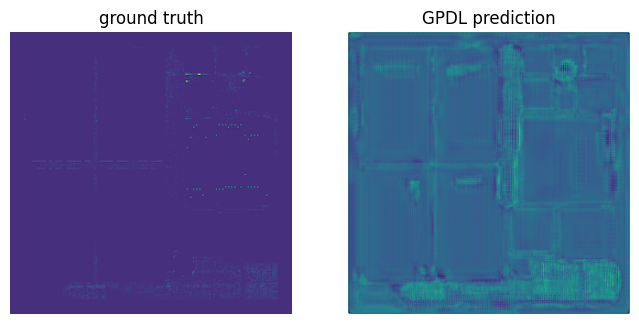

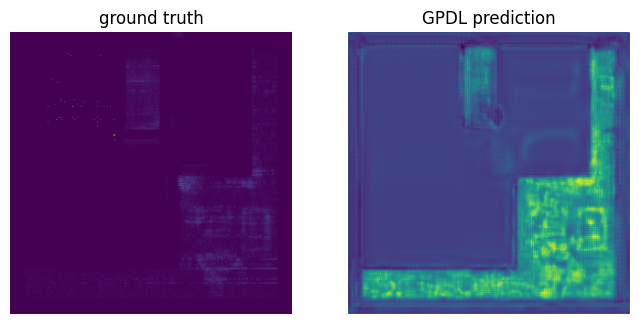

In [5]:
import json
with open('results/baseline/baseline_metrics.json') as f:
    print(json.dumps(json.load(f), indent=2))

from IPython.display import Image, display
import os
for f in sorted(os.listdir('results/baseline'))[:3]:
    if f.endswith('.png'):
        display(Image(f'results/baseline/{f}'))
